In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter 
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import CSVLoader
from langchain_core.output_parsers import StrOutputParser
from langchain_core.tools import Tool
from langgraph.prebuilt import ToolNode
from typing import Annotated,Sequence, TypedDict
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_groq import ChatGroq
from typing import Literal
from pydantic import BaseModel, Field
from langgraph.graph import END, StateGraph, START,MessagesState
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage,AIMessage,ToolMessage
from pprint import pprint
from langgraph.types import Command
from langchain.agents import create_agent
from dotenv import load_dotenv
import os
import operator
from langchain_core.runnables import  RunnablePassthrough
from docx import Document
from langgraph.checkpoint.memory import MemorySaver


c:\Users\hardi\OneDrive\Desktop\pharma project\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()

os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
llm = ChatGroq(model_name="openai/gpt-oss-120b",temperature=0)

In [5]:
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

C:\Users\hardi\AppData\Local\Temp\ipykernel_14544\2638282144.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [6]:
file_path=r"C:\Users\hardi\OneDrive\Desktop\pharma project\final_disease_drug_mapping.csv"
loader=CSVLoader(file_path)
data=loader.load()
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5",encode_kwargs={"batch_size": 256})
vectorstore = FAISS.from_documents(data, embeddings)

In [7]:
retriever=vectorstore.as_retriever(search_type="similarity",search_kwargs={"k":3})
retriever.invoke("medicine for fever")

[Document(id='36fdf84b-c5e8-4ec5-886a-374090bf4282', metadata={'source': 'C:\\Users\\hardi\\OneDrive\\Desktop\\pharma project\\final_disease_drug_mapping.csv', 'row': 356}, page_content='mesh_id: D005334\ndisease_name: Fever\ndrugbank_id: DB00118\ndrug_name: Ademetionine'),
 Document(id='5d02d8c1-0ee5-44c3-b61a-79d7470a9025', metadata={'source': 'C:\\Users\\hardi\\OneDrive\\Desktop\\pharma project\\final_disease_drug_mapping.csv', 'row': 41}, page_content='mesh_id: D005334\ndisease_name: Fever\ndrugbank_id: DB04381\ndrug_name: Crotonaldehyde'),
 Document(id='5e022a09-a20f-474d-8fc7-4c670658f9d3', metadata={'source': 'C:\\Users\\hardi\\OneDrive\\Desktop\\pharma project\\final_disease_drug_mapping.csv', 'row': 353}, page_content='mesh_id: D014435\ndisease_name: Typhoid Fever\ndrugbank_id: DB00675\ndrug_name: Tamoxifen')]

In [8]:
class SupervisorRouter(TypedDict):
    next1: Literal["Researcher","Hospital","Reporter"]
class Agent1Router(TypedDict):
    next2: Literal["Chemist","Hospital","Supervisor"]
class Agent2Router(TypedDict):
    next3: Literal["Summarizer","DocGenerator","Supervisor"]
class State(MessagesState):
    next1:str
    next2:str
    next3:str
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [ ]:
def supervisor_agent(state:State)->Command[Literal["Researcher","Reporter","__end__"]]:
    system_prompt="""You are a supervisor who routes the tasks to appropriate agents based on the user query.
    If the query is related to research about medicine,treatment or any medical problems, route it to Researcher. If the query is realted to summazrizing or making a report of the findings, route it to Reporter.
    Be strict about the following:-
    -If the query contains words like "research", "study", "investigate", "analyze", "data", "experiment", "clinical trial", "medical research", "pharmaceutical research","hospital" or words like that route it to Researcher.
    -If the query contains words like "report", "summary", "summarize", "findings", "conclusion", "document", "write-up", route it to Reporter.
    -Carefully read the user’s message.
    - If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.
    - Do **not** invent tasks or assign actions unless the message clearly demands it. 
    # Each worker will return results after completing their task.
    # Once all necessary tasks are completed, end the flow by responding with `FINISH`"""

    messages = [{"role": "system", "content": system_prompt},] + state["messages"]
    llm_w_st_op=llm.with_structured_output(SupervisorRouter)
    result=llm_w_st_op.invoke(messages)
    goto=result["next1"]
    return Command(goto=goto,update={"next1":goto})

def researcher_agent(state:State)->Command[Literal["Chemist","Hospital","Supervisor"]]:
    prompt="""You are a heirarchy supervisor who routes the tasks to appropriate agents based on the user query.
    If the query is related to research about medicine, or any medical problems, route it to Chemist. If the query is realted to hospital or treatment, route it to Reporter.
    Be strict about the following:-
    -If the query contains words like "medicine", "drug", "medical research", "pharmaceutical research" or words like that route it to Chemist.
    -If the query contains words like "hospital", "sutreatment", "symptomps", "clinic", "research", "dental", "surgery", route it to Hospital.
    -Carefully read the user’s message.
    # Each worker will return results after completing their task.
    # Once all necessary tasks are completed, end the flow by responding with `FINISH`. and send it to Supervisor."""
    messages = [{"role": "system", "content": prompt},] + state["messages"]
    llm_w_st_op=llm.with_structured_output(Agent1Router)
    result=llm_w_st_op.invoke(messages)
    goto=result["next2"]
    return Command(goto=goto,update={"next2":goto})

def chemist_agent(state:State)->Command[Literal["__end__"]]:
    question = state["messages"][-1].content
    docs = retriever.invoke(question)
    context = "\n\n".join([d.page_content for d in docs])
    prompt=ChatPromptTemplate.from_messages([
        ("system","You are a helpful medical assistant/chemist. Use the following pieces of medical data to answer the question at the end.This is a CSV file that will provide you diseasename and drug name, match it with the user's disease and symptoms and then tell the specific drug/medicine name. If you don't know the answer, just say that you don't know , don't try to make up an medicine that will harm.If you find any conflict in drug then confirm with drug agent dont proceed to give answer.Once you finish your research, respond with `FINISH`"),
        ("user","Context:\n{context}\n\nQuestion:\n{question}"),])
    chain = prompt | llm | StrOutputParser()
    response = chain.invoke({"context": context, "question": question})
    return Command(update={"messages": [AIMessage(content=response, name="disease_drug_agent")]},goto=END)

def hospital_agent(state: State) -> Command[Literal["__end__"]]:
    hospital_agent = create_agent(llm, tools=[search_tool], system_prompt="You are a researcher for finding good and trustable hospitals or finding symptomps for general medical/health problems.Once you finish your research, respond with `FINISH`")
    question = state["messages"][-1].content
    result = hospital_agent.invoke({"messages":question})
    return Command(update={"messages": [AIMessage(content=result["messages"][-1].content, name="hospital_agent") ]}, goto=END)

def reporter_agent(state: State) -> Command[Literal["Summarizer","DocGenerator","Supervisor"]]:
    prompt="""You are a medical reporter who creates reports based on the research findings provided by other agents.
    Your task is to compile the information into a coherent and concise report.
    Be strict about the following:-
    -If the query contains words like "report", "summary", "summarize", "findings", "conclusion", "document", "write-up", route it to Reporter.
    -Carefully read the user’s message.
    - If the message is general, conversational, or does **not** require any specific action, immediately respond with `FINISH`.
    - Do **not** invent tasks or assign actions unless the message clearly demands it. 
    # Each worker will return results after completing their task.
    # Once all necessary tasks are completed, end the flow by responding with `FINISH`"""
    messages = [{"role": "system", "content": prompt},] + state["messages"]
    llm_w_st_op=llm.with_structured_output(Agent2Router)
    result=llm_w_st_op.invoke(messages)
    goto=result["next3"]
    return Command(goto=goto,update={"next3":goto})

def summarizer_agent5(state:State)->Command[Literal["__end__"]]:
    conversation_text = "\n".join([getattr(m, "content", str(m)) for m in state["messages"]])
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a summarizer. Produce a short, factual summary."),
        ("user", "Conversation:\n{conversation}\n\nSummary:")
    ])
    chain = prompt | llm | StrOutputParser()
    summary = chain.invoke({"conversation": conversation_text})
    return Command(update={"messages":[AIMessage(content=summary, name="Summarizer")]}, goto=END)

def generate_medical_report(disease, symptoms, medicine, hospital, filename="medical_report.docx"):
    document = Document()

    document.add_heading('Medical Report', level=0)

    document.add_heading('Patient Condition', level=1)
    document.add_paragraph(
        f"Disease Identified: {disease}",
        style="Intense Quote"
    )

    document.add_heading('Symptoms', level=1)
    for s in symptoms:
        document.add_paragraph(f"- {s}", style='List Bullet')

    document.add_heading('Recommended Medication', level=1)
    document.add_paragraph(f"Suggested medicine: {medicine}")

    if hospital:
        document.add_heading('Nearest Suitable Hospital', level=1)
        document.add_paragraph(hospital)

    document.add_page_break()
    document.add_paragraph("This is an auto-generated report based on user input.")

    document.save(filename)
    return filename

def doc_generator_agent6(state: State) -> Command[Literal["__end__"]]:
    text = state["messages"][-1].content
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Extract fields: disease, symptoms (list comma-separated), medicine, hospital. Reply as JSON."),
        ("user", "{text}")
    ])
    messages = [{"role":"system","content":"Return a valid JSON object with keys disease, symptoms, medicine, hospital."},
                {"role":"user","content": text}]
    raw = llm.invoke(messages)
    try:
        info = json.loads(raw)
    except Exception:
        info = {"disease": text, "symptoms": [], "medicine": "", "hospital": ""}
    file = generate_medical_report(
        disease=info.get("disease",""),
        symptoms=info.get("symptoms",[]),
        medicine=info.get("medicine",""),
        hospital=info.get("hospital",""),
        filename="final_report.docx"
    )
    return Command(update={"messages":[AIMessage(content=f"Report generated: {file}", name="DocGenerator")]}, goto=END)


In [145]:
workflow=StateGraph(State)
workflow.add_node("Supervisor", supervisor_agent)
workflow.add_node("Researcher", researcher_agent)
workflow.add_node("Chemist", chemist_agent)
workflow.add_node("Hospital", hospital_agent)
workflow.add_node("Reporter",reporter_agent)
workflow.add_node("Summarizer",summarizer_agent5)
workflow.add_node("DocGenerator",doc_generator_agent6)
workflow.add_edge(START,"Supervisor")
workflow.add_edge("Summarizer", END)
workflow.add_edge("DocGenerator", END)
app=workflow.compile()

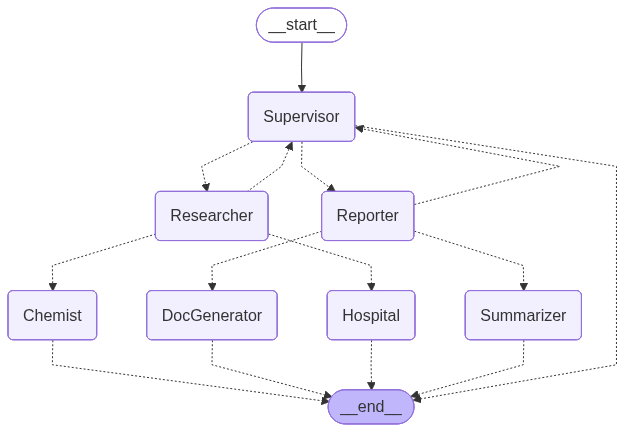

In [146]:
app

In [151]:
res = app.invoke({"messages":[HumanMessage(content=" treatement for malaria?")]})
print("FINAL:", res["messages"][-1].content)

FINAL: **Malaria Treatment – Current WHO‑Recommended Regimens (2023‑2024)**  

| Clinical situation | Recommended drug(s) | Key points & dosing (adults) | Special populations |
|--------------------|---------------------|------------------------------|---------------------|
| **Uncomplicated *Plasmodium falciparum*** | **Artemisinin‑based Combination Therapy (ACT)** – any of the following: <br>• **Artemether‑lumefantrine (AL)** 4 tablets (20 mg/120 mg) twice daily for 3 days  <br>• **Artesunate‑amodiaquine (AS‑AQ)** 1 tablet (100 mg/200 mg) once daily for 3 days  <br>• **Dihydroartemisinin‑piperaquine (DHA‑PQ)** 1 tablet (40 mg/320 mg) once daily for 3 days  <br>• **Artesunate‑mefloquine (AS‑MQ)** 1 tablet (100 mg/250 mg) once daily for 3 days  | • Complete the full 3‑day course even if symptoms resolve. <br>• Take with food (especially fatty food for AL) to improve absorption. <br>• Monitor for vomiting; if vomiting occurs within 30 min, repeat dose. | • **Pregnancy (2nd/3rd trimester

In [152]:
res

{'messages': [HumanMessage(content=' treatement for malaria?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='**Malaria Treatment – Current WHO‑Recommended Regimens (2023‑2024)**  \n\n| Clinical situation | Recommended drug(s) | Key points & dosing (adults) | Special populations |\n|--------------------|---------------------|------------------------------|---------------------|\n| **Uncomplicated *Plasmodium falciparum*** | **Artemisinin‑based Combination Therapy (ACT)** – any of the following: <br>• **Artemether‑lumefantrine (AL)** 4 tablets (20\u202fmg/120\u202fmg) twice daily for 3\u202fdays  <br>• **Artesunate‑amodiaquine (AS‑AQ)** 1 tablet (100\u202fmg/200\u202fmg) once daily for 3\u202fdays  <br>• **Dihydroartemisinin‑piperaquine (DHA‑PQ)** 1 tablet (40\u202fmg/320\u202fmg) once daily for 3\u202fdays  <br>• **Artesunate‑mefloquine (AS‑MQ)** 1 tablet (100\u202fmg/250\u202fmg) once daily for 3\u202fdays  | • Complete the full 3‑day course even if symptoms resolve